Для проекта был выбран датасет Covertype из UCI Machine Learning Repository, так как он соответствует задаче многоклассовой классификации и содержит реальные картографические и природные признаки, по которым требуется предсказать тип лесного покрова. Важным преимуществом датасета является его размер — 581,012 наблюдений, что достаточно для сравнения нескольких моделей и проведения содержательных экспериментов без проблемы “слишком маленькой выборки”.

Настройка путей, импорт библиотек

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/mnchk/hseml-group-project-mnchik


In [5]:
%pip install -U ucimlrepo

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
from src.data.load_data import load_raw_data
from src.data.validate_data import validate_schema, summarize_dataset
from src.data.preprocess import clean_data, report_data_quality, check_binary_integrity
from src.config import NUM_COLS, WILDERNESS_COLS, SOIL_COLS, TARGET_COL

Загрузка данных

In [5]:
df = load_raw_data()

In [6]:
validate_schema(df)

In [7]:
summary = summarize_dataset(df)

Вывод информации по датасету, проверка что подходит основным требованиям из ТЗ

In [8]:
summary

{'rows': 581012,
 'cols': 55,
 'missing_total': 0,
 'duplicates': 0,
 'target_classes': [1, 2, 3, 4, 5, 6, 7]}

In [9]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [10]:
df.shape

(581012, 55)

In [11]:
df.dtypes

Elevation                             int64
Aspect                                int64
Slope                                 int64
Horizontal_Distance_To_Hydrology      int64
Vertical_Distance_To_Hydrology        int64
Horizontal_Distance_To_Roadways       int64
Hillshade_9am                         int64
Hillshade_Noon                        int64
Hillshade_3pm                         int64
Horizontal_Distance_To_Fire_Points    int64
Wilderness_Area1                      int64
Soil_Type1                            int64
Soil_Type2                            int64
Soil_Type3                            int64
Soil_Type4                            int64
Soil_Type5                            int64
Soil_Type6                            int64
Soil_Type7                            int64
Soil_Type8                            int64
Soil_Type9                            int64
Soil_Type10                           int64
Soil_Type11                           int64
Soil_Type12                     

In [12]:
df = clean_data(df)

In [13]:
missing = df.isna().sum()
missing

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0
Soil_Type12                           0
Soil_Type13                           0
Soil_Type14                           0


In [14]:
print("Total missing values:", df.isna().sum().sum())

Total missing values: 0


Пропусков нет

In [15]:
print(df.dtypes.value_counts())

Int64    45
int64    10
Name: count, dtype: int64


Проверка one-hot групп

In [16]:
binary_check = check_binary_integrity(df)

for col, values in list(binary_check.items())[:10]:
    print(col, values)

Wilderness_Area1 [0, 1]
Wilderness_Area2 [0, 1]
Wilderness_Area3 [0, 1]
Wilderness_Area4 [0, 1]
Soil_Type1 [0, 1]
Soil_Type2 [0, 1]
Soil_Type3 [0, 1]
Soil_Type4 [0, 1]
Soil_Type5 [0, 1]
Soil_Type6 [0, 1]


In [17]:
bad_binary_cols = {
    col: sorted(df[col].dropna().unique().tolist())
    for col in WILDERNESS_COLS + SOIL_COLS
    if set(df[col].dropna().unique().tolist()) - {0, 1}
}

bad_binary_cols

{}

Проблемных столбцов нет

Далее проверка что ровна 1 единица в каждой группе

In [18]:
wilderness_sum = df[WILDERNESS_COLS].sum(axis=1)
soil_sum = df[SOIL_COLS].sum(axis=1)

print("Wilderness rows with sum != 1:", (wilderness_sum != 1).sum())
print("Soil rows with sum != 1:", (soil_sum != 1).sum())

Wilderness rows with sum != 1: 0
Soil rows with sum != 1: 0


Выведем статистику для колонок числовых

In [19]:
df[NUM_COLS].describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000


Округлю до 2 знаков после запятой

In [20]:
df[NUM_COLS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Elevation,581012.0,2959.37,279.98,1859.0,2809.0,2996.0,3163.0,3858.0
Aspect,581012.0,155.66,111.91,0.0,58.0,127.0,260.0,360.0
Slope,581012.0,14.10,7.49,0.0,9.0,13.0,18.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.43,212.55,0.0,108.0,218.0,384.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.42,58.30,-173.0,7.0,30.0,69.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.15,1559.25,0.0,1106.0,1997.0,3328.0,7117.0
Hillshade_9am,581012.0,212.15,26.77,0.0,198.0,218.0,231.0,254.0
Hillshade_Noon,581012.0,223.32,19.77,0.0,213.0,226.0,237.0,254.0
Hillshade_3pm,581012.0,142.53,38.27,0.0,119.0,143.0,168.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.29,1324.20,0.0,1024.0,1710.0,2550.0,7173.0


Можно сделать вывод что пропусков в числовых признаках нет и признаки измеряются в очень разных шкалах.

Посмотрим boxplot для проверки выбросов и распределения

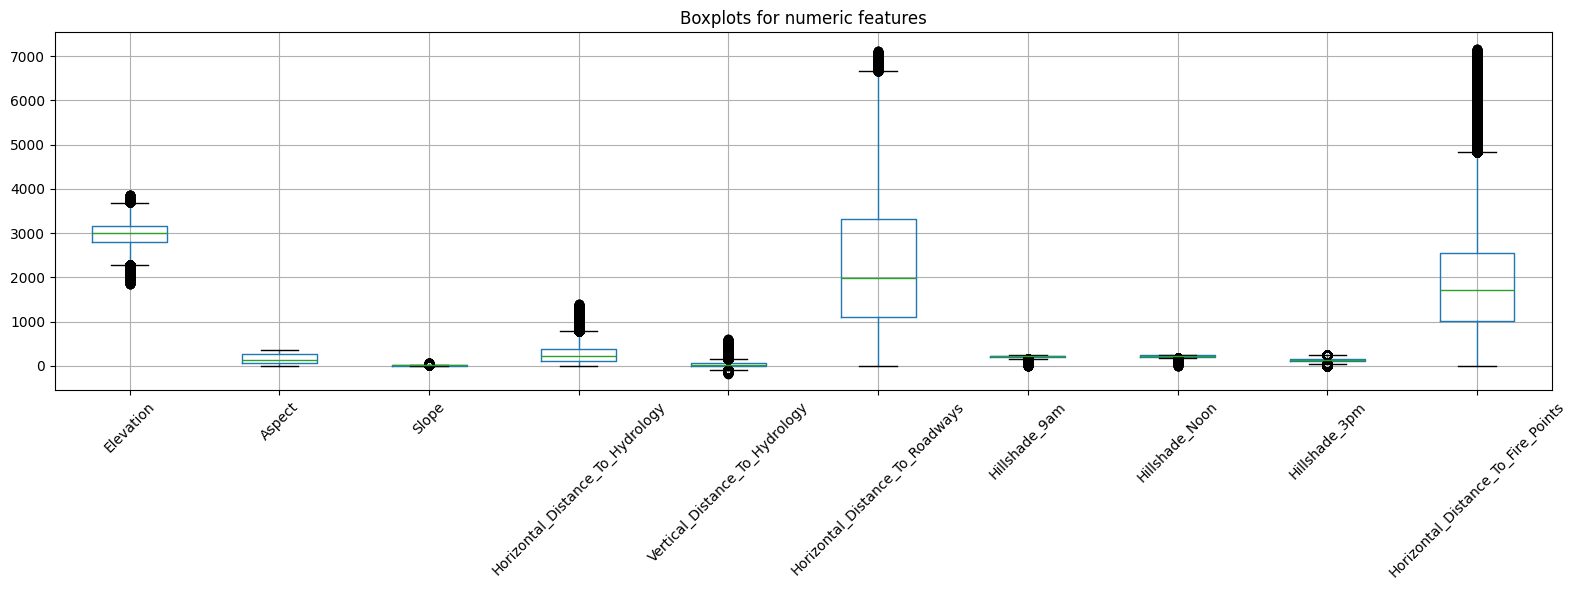

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
df[NUM_COLS].boxplot(rot=45)
plt.title("Boxplots for numeric features")
plt.tight_layout()
plt.show()

Выведу покрасивее

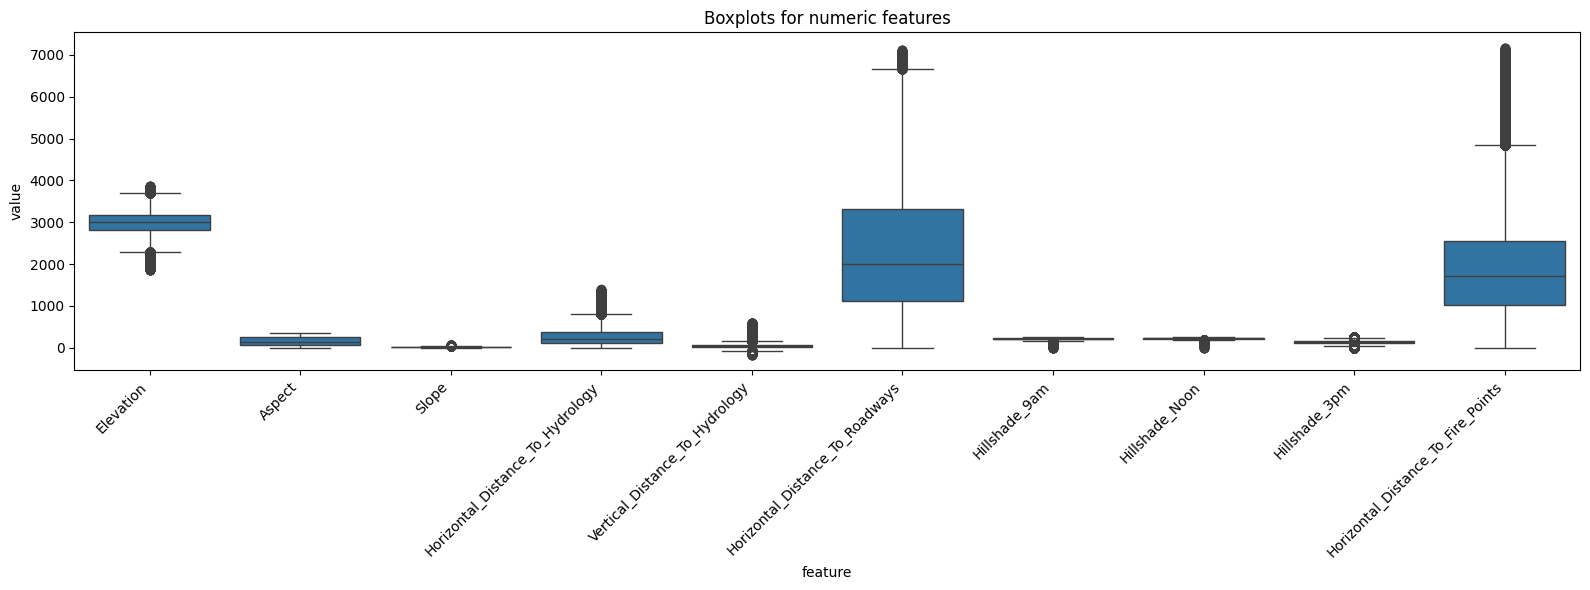

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = Path("../report/images").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

df_melted = df[NUM_COLS].melt(var_name="feature", value_name="value")

plt.figure(figsize=(16, 6))
sns.boxplot(data=df_melted, x="feature", y="value")
plt.xticks(rotation=45, ha="right")
plt.title("Boxplots for numeric features")
plt.tight_layout()
plt.savefig(output_dir / "boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## выводы 
- разные масштабы признаков (Elevation и расстояния до дорог/очагов пожара измеряются в тысячах метров, а Slope и Aspect лежат в совершенно другом диапазоне)
- сильная асимметрия и длинные хвосты
- наличие большого числа выбросов, но они выглядят реалистично (будто бы это отдаленные участки леса)
- ни один числовой признак не вырожден в константу, что подтверждает их потенциальную полезность для модели

In [23]:
quality_report = report_data_quality(df)

print("Duplicates:", quality_report["duplicates"])
print("Total missing:", sum(quality_report["missing_by_column"].values()))

Duplicates: 0
Total missing: 0


/var/folders/w7/yq0yv5y9281c04rncy1535jm0000gn/T/ipykernel_28190/2034925068.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Cover_Type", palette="viridis")


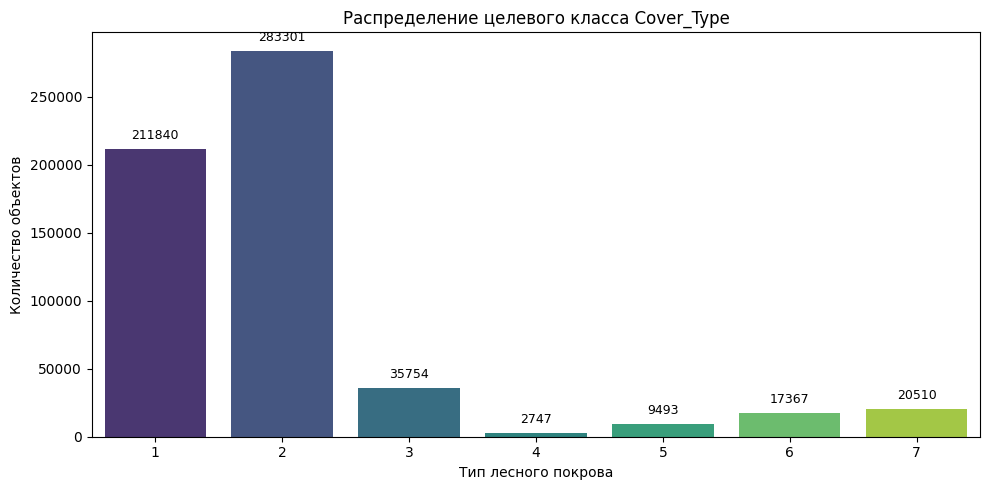

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = Path("../report/images").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x="Cover_Type", palette="viridis")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 5),
        textcoords="offset points",
    )

plt.title("Распределение целевого класса Cover_Type")
plt.xlabel("Тип лесного покрова")
plt.ylabel("Количество объектов")
plt.tight_layout()
plt.savefig(output_dir / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
target_counts = df["Cover_Type"].value_counts().sort_index()
target_share = (df["Cover_Type"].value_counts(normalize=True).sort_index() * 100).round(2)

display(target_counts)
display(target_share)

Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: Int64

Cover_Type
1    36.46
2    48.76
3     6.15
4     0.47
5     1.63
6     2.99
7     3.53
Name: proportion, dtype: Float64

Распределение классов Cover_Type не является идеально равномерным, поэтому уже на этапе EDA важно учитывать дисбаланс классов при выборе метрик и интерпретации результатов модели.

In [26]:
from pathlib import Path

interim_path = Path("../data/interim").resolve()
interim_path.mkdir(parents=True, exist_ok=True)

df.to_csv(interim_path / "covertype_clean.csv", index=False)

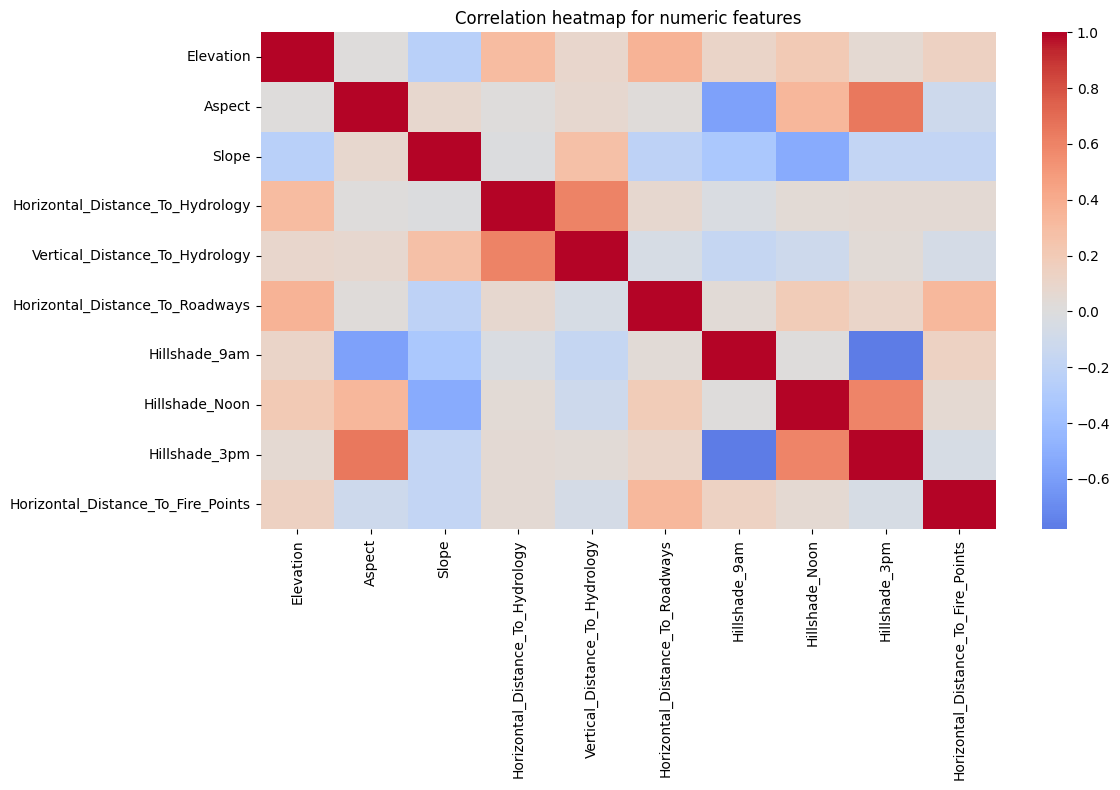

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import NUM_COLS

plt.figure(figsize=(12, 8))
corr = df[NUM_COLS].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap for numeric features")
plt.tight_layout()
plt.savefig(output_dir / "Correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

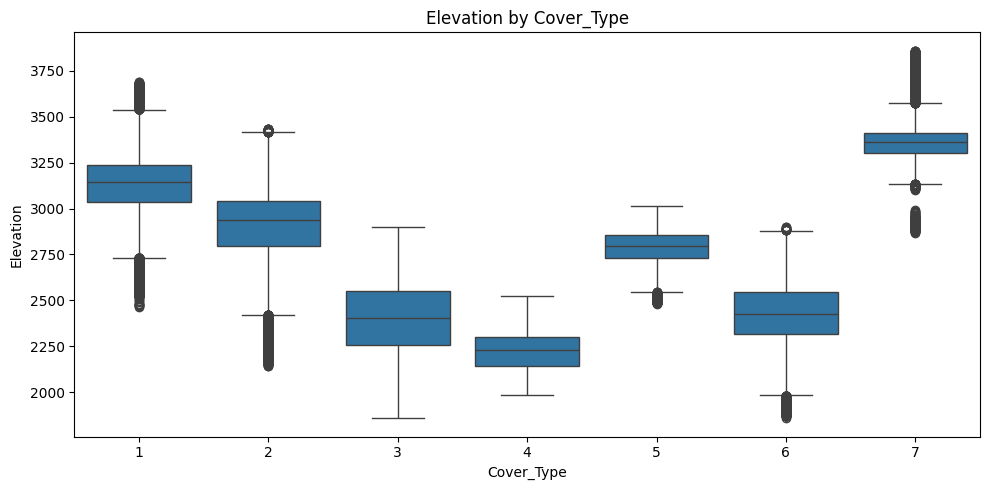

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Cover_Type", y="Elevation")
plt.title("Elevation by Cover_Type")
plt.tight_layout()
plt.savefig(output_dir / "Elevation_by_Cover_Type.png", dpi=300, bbox_inches="tight")
plt.show()

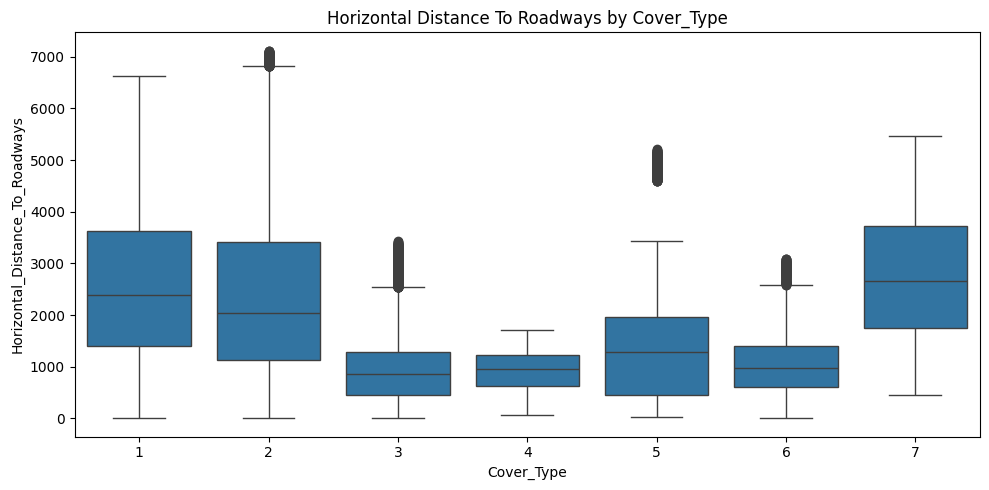

In [47]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Cover_Type", y="Horizontal_Distance_To_Roadways")
plt.title("Horizontal Distance To Roadways by Cover_Type")
plt.tight_layout()
plt.savefig(output_dir / "Horizontal_Distance.png", dpi=300, bbox_inches="tight")
plt.show()

На этапе подготовки данных были проверены пропуски, дубли, типы данных и корректность one-hot признаков. Пропуски в основных признаках не обнаружены, а значения в группах Wilderness_Area и Soil_Type соответствуют бинарному кодированию 0/1, что согласуется с документацией UCI. Для числовых признаков были рассчитаны описательные статистики и построены boxplot-графики, показавшие наличие длинных хвостов и выбросов в расстояниях до дорог, гидрографии и точек возгорания, однако эти наблюдения интерпретируются как реалистичные для геопространственных данных, а не как ошибки ввода.

В конце псделала и самостоятельный парсинг, но те выводы оставлю так

In [44]:
import importlib
import src.data.parse_raw as parse_raw

importlib.reload(parse_raw)

df_bonus = parse_raw.build_bonus_parsed_dataset()
df_bonus.shape, df_bonus.head()

((581012, 55),
    Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
 0       2596      51      3                               258   
 1       2590      56      2                               212   
 2       2804     139      9                               268   
 3       2785     155     18                               242   
 4       2595      45      2                               153   
 
    Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
 0                               0                              510   
 1                              -6                              390   
 2                              65                             3180   
 3                             118                             3090   
 4                              -1                              391   
 
    Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
 0            221             232            148   
 1            220             235            151   
 2 

Помимо стандартной загрузки датасета была реализована самостоятельная обработка исходного архива с данными, скачанного с UCI Machine Learning Repository. Из локального ZIP-файла, содержащего Covertype, программно извлекался сырой файл covtype.data.gz, распаковывался в текстовый формат и парсился в pandas.DataFrame с явным заданием имён всех признаков и целевой переменной. Полученный набор данных сохранялся в отдельный файл covertype_parsed_bonus.csv, что демонстрирует корректный ручной парсинг и может использоваться для валидации совпадения с основной версией датасета.

В исходном датасете 54 признака: 10 количественных и 44 бинарных. Для улучшения качества модели можно построить дополнительные производные признаки, отражающие геометрические и экологические зависимости между исходными переменными.

In [48]:
from src.features.build_features import add_features

df_features = add_features(df)

print("Исходное число признаков:", df.shape[1] - 1)
print("Новое число признаков:", df_features.shape[1] - 1)
print("Добавлено признаков:", df_features.shape[1] - df.shape[1])

Исходное число признаков: 54
Новое число признаков: 59
Добавлено признаков: 5


После базовой очистки был выполнен feature engineering. Были добавлены признаки, отражающие евклидово расстояние до гидрографии, среднюю освещённость, разность расстояний до дорог и точек возгорания, а также взаимодействие высоты и уклона; это позволяет модели учитывать более сложные зависимости, чем те, которые выражены в исходных столбцах напрямую.

In [49]:
from pathlib import Path

interim_dir = Path("../data/interim").resolve()
processed_dir = Path("../data/processed").resolve()

interim_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(interim_dir / "covertype_clean.csv", index=False)
df_features.to_csv(processed_dir / "covertype_features.csv", index=False)

Для оценки модели нужен раздельный train/val/test split. Разделение должно быть stratified, чтобы сохранить пропорции классов, а все преобразования вроде масштабирования, PCA и отбора признаков должны обучаться только на train-части, иначе возникает утечка данных. Подготовка признаков до разделения на train/test может приводить к leakage, поэтому корректный подход — сначала split, потом fit трансформаций только на train через Pipeline.